## Building the scoring pipeline: zscore and combine

Goal: `scoring/zscore.py` and `scoring/combine.py` are the next step per the README's build
order, since `size.py`, `value.py`, and `quality.py` all sit on top of them. Before writing
either, resolve one open design question: whether cross sectional z-scoring needs outlier
handling beyond a plain mean and standard deviation, since a ratio such as earnings to price
can carry extreme values from a near-zero denominator.

Start by looking at a real ratio's cross sectional distribution rather than deciding this in
the abstract, the same approach that found the fundamentals loader's period resolution defects
by measuring outcomes at scale rather than reasoning from the API documentation alone.

## Part 1: does a raw value ratio actually have outliers worth handling?

Pull net income, shares outstanding, and price for a broad sample of S&P 500 members on one
recent date, compute a raw earnings yield (`net_income / market_cap`) for each, and look at the
distribution: `describe()`, a histogram, and the most extreme values by ticker.

The fundamentals loader's own validation panel (`PANEL` in
`notebooks/validating_fundamentals.ipynb`) is deliberately built from edge cases (banks with no
revenue tag, a foreign filer with none at all), which makes it a poor proxy for an ordinary
cross section. A plain random sample from `build_universe()`'s current membership is closer to
what a real rebalance date looks like.

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import random
from src.universe.point_in_time import build_universe, ticker_on
from src.loaders.fundamentals import build_fundamentals, load_company_facts, latest_value_as_of, shares_outstanding_as_of
from src.loaders.prices import build_prices, load_cik_prices


universe_spans, ticker_history = build_universe()
build_fundamentals()
build_prices()

AS_OF = "2024-06-28"   # a recent Friday, arbitrary

active = universe_spans[
    (universe_spans["start_date"] <= AS_OF)
    & (universe_spans["end_date"].isna() | (universe_spans["end_date"] >= AS_OF))
]
sample_ciks = random.sample(list(active["cik"].dropna().unique()), 60)

rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    if facts is None:
        continue
    ni = latest_value_as_of(facts, "net_income", "USD", AS_OF, period="annual")
    shares = shares_outstanding_as_of(facts, AS_OF)
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if ni is None or shares is None or ticker is None or prices is None:
        continue
    # ni and shares are tuples: (val, filed, form, tag, period_end/end), not bare numbers
    # ... still open: look up the close price for `ticker` on/near AS_OF from `prices`
    #     (filter prices["ticker"] == ticker first — a CIK's file can hold more than one),
    #     then market_cap = shares[0] * close, earnings_yield = ni[0] / market_cap


In [2]:
import pandas as pd

def close_on_or_before(prices, ticker, as_of):
    """Point in time close: the most recent trading day at or before as_of.

    Never a later date, per the README's no-look-ahead rule. Returns None if
    the ticker has no data at all, or as_of predates its earliest session.
    """
    ticker_prices = prices[prices["ticker"] == ticker].sort_index()
    if ticker_prices.empty:
        return None
    as_of_ts = pd.Timestamp(as_of).tz_localize(ticker_prices.index.tz)
    close = ticker_prices.asof(as_of_ts)["Close"]
    return None if pd.isna(close) else close


In [10]:
rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    if facts is None:
        continue
    ni = latest_value_as_of(facts, "net_income", "USD", AS_OF, period="annual")
    shares = shares_outstanding_as_of(facts, AS_OF)
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if ni is None or shares is None or ticker is None or prices is None:
        continue
    close = close_on_or_before(prices, ticker, AS_OF)
    if close is None:
        continue
    market_cap = shares[0] * split_adjustment_ratio(prices, ticker, shares[4]) * close
    rows.append({
        "cik": cik, "ticker": ticker,
        "net_income": ni[0], "shares": shares[0], "close": close,
        "market_cap": market_cap,
        "earnings_yield": ni[0] / market_cap,
    })

yields = pd.DataFrame(rows)
print(f"{len(yields)} / {len(sample_ciks)} sampled CIKs resolved")
yields["earnings_yield"].describe()


54 / 60 sampled CIKs resolved


count    54.000000
mean      0.051617
std       0.045311
min      -0.167039
25%       0.029862
50%       0.043405
75%       0.076655
max       0.165072
Name: earnings_yield, dtype: float64

   ticker  earnings_yield
29    FIS       -0.167039
9      MA        0.007673
53   LDOS        0.010305
40   ZBRA        0.018634
43     IP        0.020878
   ticker  earnings_yield
24   CINF        0.104344
52    BMY        0.106193
23     CF        0.118876
39    SYF        0.122418
45    MPC        0.165072


<Axes: >

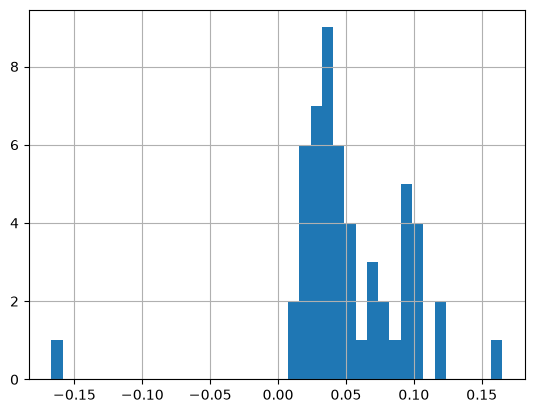

In [11]:
print(yields.sort_values("earnings_yield").head(5)[["ticker", "earnings_yield"]])
print(yields.sort_values("earnings_yield").tail(5)[["ticker", "earnings_yield"]])
yields["earnings_yield"].hist(bins=40)

## Part 2: correcting market cap for stock splits

In [7]:
def split_adjustment_ratio(prices, ticker, basis_date):
    """Cumulative split ratio between basis_date and the latest cached price date.

    Multiplying a basis-date share count by this ratio brings it onto the same
    split footing as any cached price, before or after basis_date, since split
    ratios compose across the whole interval regardless of where a query date
    falls in between.
    """
    ticker_prices = prices[prices["ticker"] == ticker].sort_index()
    basis_ts = pd.Timestamp(basis_date).tz_localize(ticker_prices.index.tz)
    later_splits = ticker_prices.loc[ticker_prices.index > basis_ts, "Stock Splits"]
    return later_splits[later_splits != 0].prod()


In [8]:
cmg_prices = load_cik_prices(1058090)
print(split_adjustment_ratio(cmg_prices, "CMG", "2024-04-22"))    # shares' own basis date; expect 50.0

orly_prices = load_cik_prices(898173)
print(split_adjustment_ratio(orly_prices, "ORLY", "2024-04-29"))  # expect 15.0, even though the split is chronologically after AS_OF

aapl_prices = load_cik_prices(320193)
print(split_adjustment_ratio(aapl_prices, "AAPL", "2024-06-28"))  # expect 1.0: no AAPL split since August 2020


50.0
15.0
1.0
